In [1]:
!nvidia-smi
!pip install ultralytics

Wed Sep  9 15:07:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import cv2


def find_dataset_root():
    input_root = '/kaggle/input/'
    detected_path = None
    for root, dirs, files in os.walk(input_root):
        if 'train' in dirs and 'valid' or 'val' in dirs:
            detected_path = root
            break
    return detected_path

REAL_BASE_PATH = find_dataset_root()
print(f"Dataset Path: {REAL_BASE_PATH}")

Dataset Path: /kaggle/input/datasets/adilshamim8/license-plate-recognition


In [3]:
base = REAL_BASE_PATH
image_extensions = {'.jpg', '.jpeg', '.png'}
total_images = 0

for root, _, files in os.walk(base):
    extensions = {}

    for filename in files:
        extension = Path(filename).suffix.lower()
        extensions[extension] = extensions.get(extension, 0) + 1

        if extension in image_extensions:
            total_images += 1

    if extensions:
        print(root, "->", extensions)

    non_images = [
        filename for filename in files
        if Path(filename).suffix.lower() not in image_extensions
    ]

    if non_images:
        print("Non-image files (CSV Files):", non_images[:10])

print(f"Total images: {total_images}")

/kaggle/input/datasets/adilshamim8/license-plate-recognition/valid/valid -> {'.jpg': 2048, '.csv': 1}
Non-image files (CSV Files): ['_annotations.csv']
/kaggle/input/datasets/adilshamim8/license-plate-recognition/test/test -> {'.jpg': 1020, '.csv': 1}
Non-image files (CSV Files): ['_annotations.csv']
/kaggle/input/datasets/adilshamim8/license-plate-recognition/train/train -> {'.jpg': 7057, '.csv': 1}
Non-image files (CSV Files): ['_annotations.csv']
Total images: 10125


In [4]:
import shutil
def annotation_directory(dataset_root, split):
    split_root = Path(dataset_root) / split
    candidates = [path for path in split_root.rglob('_annotations.csv')]
    if len(candidates) != 1:
        raise RuntimeError(f'Expected one _annotations.csv for {split}, found: {candidates}')
    return candidates[0].parent


def resolve_split_names(dataset_root):
    source_names = {'train': 'train', 'test': 'test'}
    validation_candidates = [name for name in ('valid', 'val') if (Path(dataset_root) / name).is_dir()]
    if len(validation_candidates) != 1:
        raise RuntimeError(f'Expected exactly one validation folder named valid or val, found: {validation_candidates}')
    source_names['valid'] = validation_candidates[0]
    return source_names


source_split_names = resolve_split_names(REAL_BASE_PATH)
splits = {
    output_split: annotation_directory(REAL_BASE_PATH, source_split)
    for output_split, source_split in source_split_names.items()
}
output_base = '/kaggle/working/plate_dataset_yolo'
shutil.rmtree(output_base, ignore_errors=True)

for split_name, split_path in splits.items():
    img_out = Path(output_base) / split_name / 'images'
    lbl_out = Path(output_base) / split_name / 'labels'
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(split_path / '_annotations.csv')
    print(f"\n--- {split_name.upper()} ---")
    print(df.head())
    
    for filename in df['filename'].unique():
        source_image, target_image = split_path / filename, img_out / filename
        if source_image.exists():
            target_image.symlink_to(source_image)

    for filename, group in df.groupby('filename'):
        lines = []
        for row in group.itertuples(index=False):
            x_center = ((row.xmin + row.xmax) / 2) / row.width
            y_center = ((row.ymin + row.ymax) / 2) / row.height
            width = (row.xmax - row.xmin) / row.width
            height = (row.ymax - row.ymin) / row.height
            lines.append(f'0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}')
        (lbl_out / f'{Path(filename).stem}.txt').write_text('\n'.join(lines), encoding='utf-8')

print('YOLO dataset preparation completed.')


--- TRAIN ---
                                            filename  width  height  \
0  xemay1793_jpg.rf.0dc26bab2eb4bb60c25bf0430a744...    472     303   
1  xemay1850_jpg.rf.a89277812aac9136da653af67d7e3...    472     303   
2  rotatequandoi50_jpg.rf.fcc6a91af1b79436df370a0...    764     428   
3  Cars354_png_jpg.rf.52d6d5fb18efb7075b02ccc55c4...    400     267   
4  CarLongPlateGen2076_jpg.rf.2c1888f949cec4ec6e8...    472     303   

           class  xmin  ymin  xmax  ymax  
0  License_Plate   154    82   218   127  
1  License_Plate   187   122   249   169  
2  License_Plate   260   322   325   370  
3  License_Plate    64   201   101   221  
4  License_Plate   316   242   412   271  

--- TEST ---
                                            filename  width  height  \
0  CarLongPlateGen1398_jpg.rf.621f63c834b8d9f7920...    472     303   
1  CarLongPlateGen1478_jpg.rf.0f059c716a8985f7a95...    472     303   
2  xemay1982_jpg.rf.aad83d30440aed61a12980bd01254...    472     303   
3 

In [5]:
def check_dataset_structure(base_path):
    base = Path(base_path)
    report = []

    
    splits = ['train', 'valid', 'test']
    for split in splits:
        img_dir = base / split / 'images'
        lbl_dir = base / split / 'labels'
        
        if img_dir.exists() and lbl_dir.exists():
            images = sorted([f.stem for f in img_dir.glob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png']])
            labels = sorted([f.stem for f in lbl_dir.glob('*.txt')])
            
            
            mismatched_imgs = set(images) - set(labels)
            mismatched_lbls = set(labels) - set(images)
            
            report.append({
                'Split': split,
                'Total Images': len(images),
                'Total Labels': len(labels),
                'Mismatched Images': len(mismatched_imgs),
                'Mismatched Labels': len(mismatched_lbls)
            })
        else:
            print(f"File does not exist or not valid  {split}")
            
    df_report = pd.DataFrame(report)
    print("\n--- dataset structure report---")
    print(df_report.to_string(index=False))
    return df_report
    
check_dataset_structure("/kaggle/working/plate_dataset_yolo")


--- dataset structure report---
Split  Total Images  Total Labels  Mismatched Images  Mismatched Labels
train          7052          7052                  0                  0
valid          2045          2045                  0                  0
 test          1019          1019                  0                  0


,Split,Total Images,Total Labels,Mismatched Images,Mismatched Labels
0,train,7052,7052,0,0
1,valid,2045,2045,0,0
2,test,1019,1019,0,0


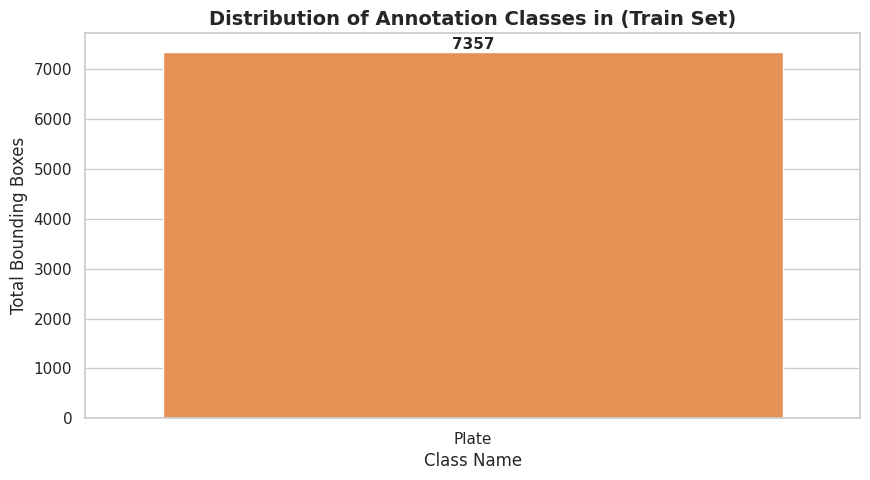


--_Classes distribution report ---
Class  Count  Percentage
Plate   7357       100.0


,Class,Count,Percentage
0,Plate,7357,100.0


In [6]:
def analyze_class_distribution(base_path, class_names, split='train'):
    label_dir = Path(base_path) / split / 'labels'
    class_counts = Counter()
    total_boxes = 0
    
    for label_file in label_dir.glob('*.txt'):
        with open(label_file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if parts:
                    class_id = int(parts[0])
                    class_counts[class_id] += 1
                    total_boxes += 1
                    
    
    data = []
    for cid, count in class_counts.items():
        name = class_names[cid] if cid < len(class_names) else f"Unknown ({cid})"
        data.append({'Class': name, 'Count': count, 'Percentage': (count / total_boxes) * 100})
        
    df_class = pd.DataFrame(data)
    
    
    plt.figure(figsize=(10, 5))
    sns.set_theme(style="whitegrid")
    ax = sns.barplot(x='Class', y='Count', data=df_class, hue='Class', palette='Oranges_r', legend=False)
    
    
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11, fontweight='bold')
        
    plt.title(f'Distribution of Annotation Classes in ({split.capitalize()} Set)', fontsize=14, fontweight='bold')
    plt.xlabel('Class Name', fontsize=12)
    plt.ylabel('Total Bounding Boxes', fontsize=12)
    plt.show()
    
    print("\n--_Classes distribution report ---")
    print(df_class.to_string(index=False))
    return df_class


class_names = {0: 'Plate'} 
analyze_class_distribution('/kaggle/working/plate_dataset_yolo', class_names, split='train')

In [7]:
EPSILON = 1e-4


def validate_labels(labels_dir, split_name):
    issues = []
    all_labels = os.listdir(labels_dir)

    for lbl_name in all_labels:
        lbl_path = os.path.join(labels_dir, lbl_name)

        with open(lbl_path) as f:
            lines = f.readlines()

        for line_num, line in enumerate(lines, start=1):
            line = line.strip()
            if line == "":
                continue

            parts = line.split()

            if len(parts) != 5:
                issues.append(
                    f"{lbl_name} (line {line_num}): invalid number of values ({len(parts)}) -> {line}"
                )
                continue

            try:
                cls, xc, yc, bw, bh = map(float, parts)
            except ValueError:
                issues.append(
                    f"{lbl_name} (line {line_num}): non-numeric value -> {line}"
                )
                continue

            if int(cls) != 0:
                issues.append(
                    f"{lbl_name} (line {line_num}): invalid class ({cls})"
                )

            for name, val in [("xc", xc), ("yc", yc), ("bw", bw), ("bh", bh)]:
                if not (-EPSILON <= val <= 1 + EPSILON):
                    issues.append(
                        f"{lbl_name} (line {line_num}): {name}={val} out of range [0, 1]"
                    )

            if bw <= 0 or bh <= 0:
                issues.append(
                    f"{lbl_name} (line {line_num}): bw={bw}, bh={bh} (zero or negative)"
                )

            x1, x2 = xc - bw / 2, xc + bw / 2
            y1, y2 = yc - bh / 2, yc + bh / 2
            if (
                x1 < -EPSILON
                or x2 > 1 + EPSILON
                or y1 < -EPSILON
                or y2 > 1 + EPSILON
            ):
                issues.append(
                    f"{lbl_name} (line {line_num}): bounding box exceeds image boundaries (x:[{x1:.6f},{x2:.6f}] y:[{y1:.6f},{y2:.6f}])"
                )

    print(
        f"\n=== {split_name}: checked {len(all_labels)} files, found {len(issues)} issues ==="
    )

    for issue in issues[:30]:
        print(" ", issue)

    if len(issues) > 30:
        print(f"  ... and {len(issues) - 30} additional issues")

    return issues


all_issues = {}
for split in ["train", "valid", "test"]:
    labels_dir = f"{output_base}/{split}/labels"
    all_issues[split] = validate_labels(labels_dir, split)


=== train: checked 7052 files, found 0 issues ===

=== valid: checked 2045 files, found 0 issues ===

=== test: checked 1019 files, found 0 issues ===


In [8]:
from collections import defaultdict
import hashlib

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png'}


def compute_file_hash(filepath, chunk_size=1024 * 1024):
    hasher = hashlib.md5()
    with open(filepath, 'rb') as file:
        for chunk in iter(lambda: file.read(chunk_size), b''):
            hasher.update(chunk)
    return hasher.hexdigest()


def hash_images(images_dir):
    hashes = defaultdict(list)
    for path in sorted(Path(images_dir).iterdir()):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            hashes[compute_file_hash(path)].append(path.name)
    return dict(hashes)


split_dirs = {split: Path(output_base) / split / 'images' for split in ('train', 'valid', 'test')}
split_hashes = {split: hash_images(images_dir) for split, images_dir in split_dirs.items()}

for left, right in [('train', 'valid'), ('train', 'test'), ('valid', 'test')]:
    shared = set(split_hashes[left]) & set(split_hashes[right])
    duplicate_images = sum(len(split_hashes[right][digest]) for digest in shared)
    print(f'{left} vs {right}: {duplicate_images} duplicate image(s), {len(shared)} unique contents')

train vs valid: 45 duplicate image(s), 45 unique contents
train vs test: 17 duplicate image(s), 17 unique contents
valid vs test: 4 duplicate image(s), 4 unique contents


In [9]:
def duplicate_rows(split_hashes, priorities=('train', 'valid', 'test')):
    """Return every lower-priority image whose content occurs in an earlier split."""
    seen_hashes = set()
    rows = []
    for split in priorities:
        for digest, filenames in split_hashes[split].items():
            if digest in seen_hashes:
                rows.extend({'split': split, 'filename': name, 'hash': digest} for name in filenames)
        seen_hashes.update(split_hashes[split])
    return pd.DataFrame(rows, columns=['split', 'filename', 'hash'])


duplicates = duplicate_rows(split_hashes)
print('Duplicates that would be removed (priority: train > valid > test):')
display(duplicates.groupby('split').size().rename('images').to_frame() if not duplicates.empty else duplicates)


Duplicates that would be removed (priority: train > valid > test):


,images
split,
test,21
valid,45


In [10]:
APPLY_DEDUPLICATION = True


def remove_duplicates(duplicates, images_root):
    removed = 0
    for row in duplicates.itertuples(index=False):
        image_path = Path(images_root) / row.split / 'images' / row.filename
        label_path = Path(images_root) / row.split / 'labels' / f'{Path(row.filename).stem}.txt'
        for path in (image_path, label_path):
            if path.exists() or path.is_symlink():
                path.unlink()
        removed += 1
    return removed


if APPLY_DEDUPLICATION:
    removed_count = remove_duplicates(duplicates, output_base)
    print(f'Removed {removed_count} duplicate image/label pair(s).')
else:
    print('No files deleted. Set APPLY_DEDUPLICATION = True to apply the reviewed cleanup.')


Removed 66 duplicate image/label pair(s).


In [11]:
from PIL import Image

def check_image_integrity(images_dir, split_name):
    issues = []
    all_images = os.listdir(images_dir)

    widths = []
    heights = []

    for img_name in all_images:
        img_path = os.path.join(images_dir, img_name)

        img = cv2.imread(img_path)
        if img is None:
            issues.append(
                f"{img_name}: cv2.imread returned None (corrupted file or unsupported format)"
            )
            continue

        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

        if w < 10 or h < 10:
            issues.append(f"{img_name}: extremely small dimensions ({w}x{h})")

        try:
            with Image.open(img_path) as pil_img:
                pil_img.verify()
        except Exception as e:
            issues.append(f"{img_name}: PIL verify failed -> {e}")

    print(
        f"\n=== {split_name}: checked {len(all_images)} images, found {len(issues)} issues ==="
    )
    for issue in issues[:20]:
        print(" ", issue)
    if len(issues) > 20:
        print(f"  ... and {len(issues) - 20} additional issues")

    if widths:
        print(
            f"  Dimensions: width [{min(widths)} - {max(widths)}], height [{min(heights)} - {max(heights)}]"
        )

    return issues


for split in ["train", "valid", "test"]:
    images_dir = f"{output_base}/{split}/images"
    check_image_integrity(images_dir, split)


=== train: checked 7052 images, found 0 issues ===
  Dimensions: width [90 - 5312], height [86 - 4608]

=== valid: checked 2000 images, found 0 issues ===
  Dimensions: width [100 - 5312], height [100 - 4032]

=== test: checked 998 images, found 0 issues ===
  Dimensions: width [100 - 4000], height [100 - 4032]


In [12]:
yaml_content = f"""
train: {output_base}/train/images
val: {output_base}/valid/images
test: {output_base}/test/images

nc: 1
names: ['plate']
"""
with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)
if os.path.isfile("/kaggle/working/data.yaml"):
    print("Yaml file has been created")

Yaml file has been created


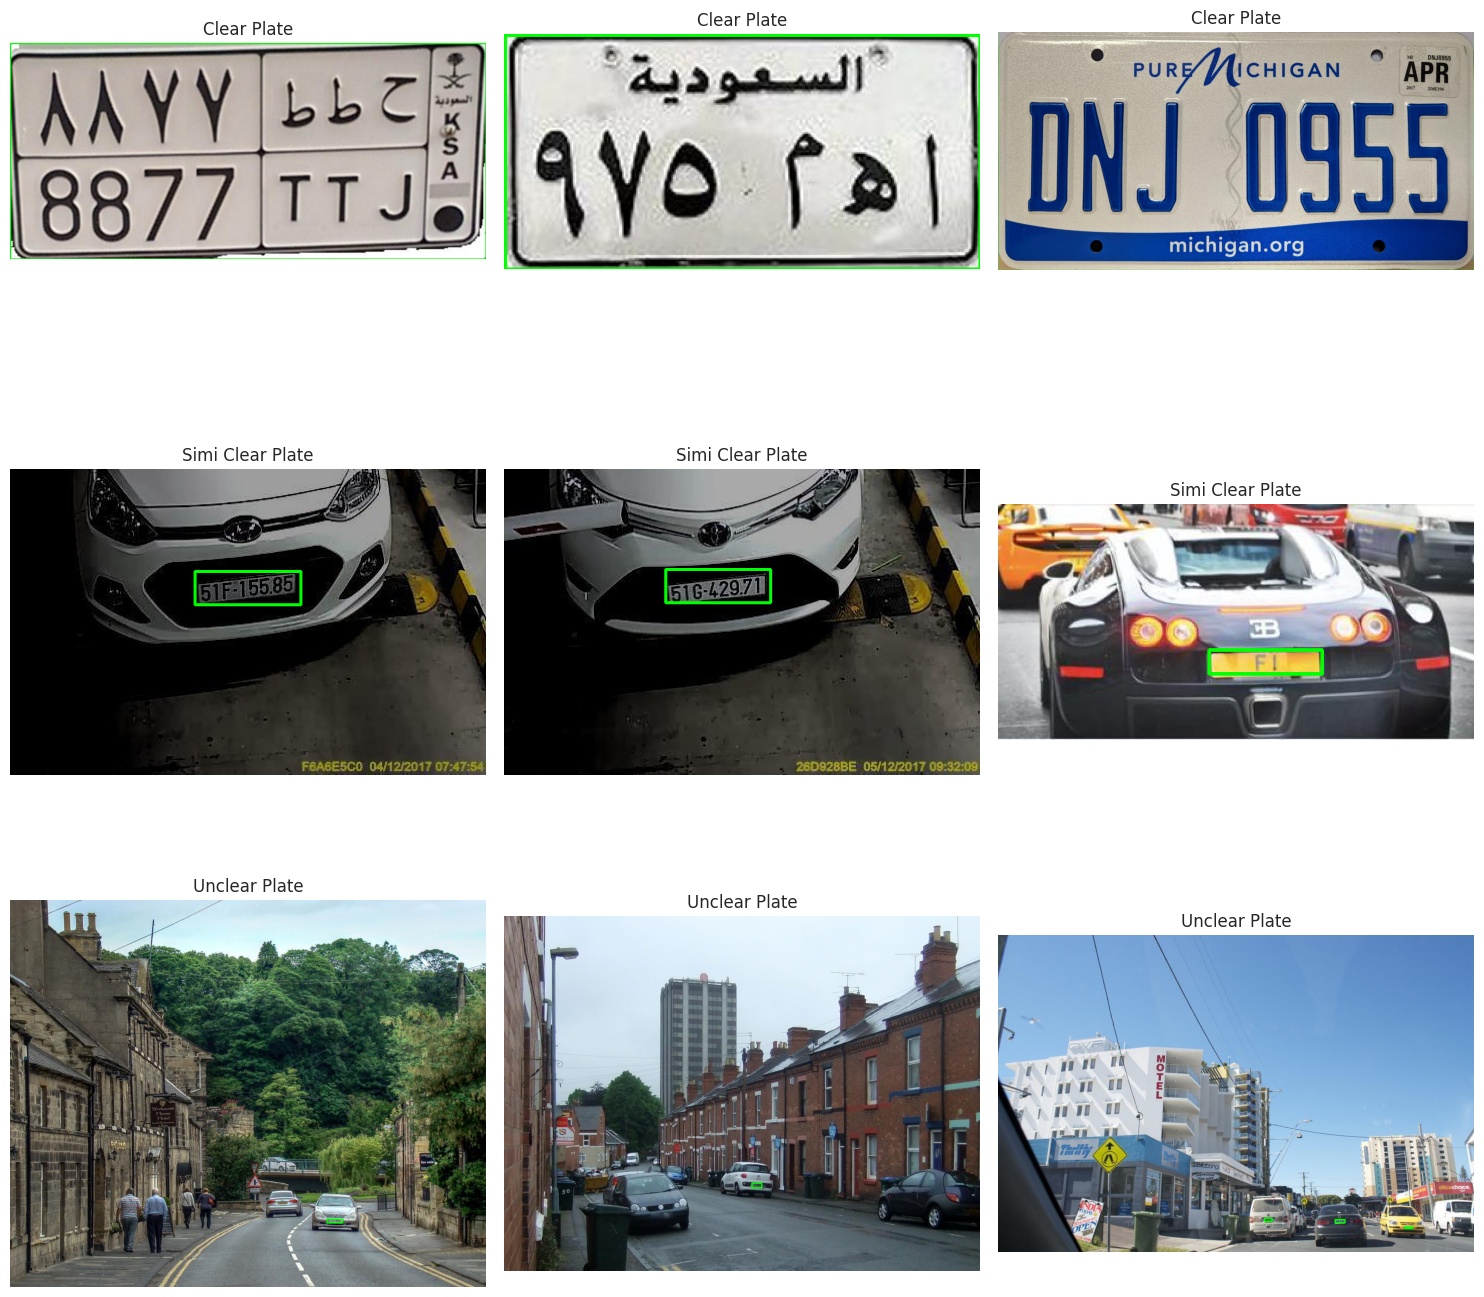

In [13]:
def draw_boxes(img_path, lbl_path):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                if line.strip() == "":
                    continue
                cls, xc, yc, bw, bh = map(float, line.split())
                x1 = int((xc - bw/2) * w)
                y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w)
                y2 = int((yc + bh/2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


images_dir = f"{output_base}/train/images"
labels_dir = f"{output_base}/train/labels"
all_images = sorted(os.listdir(images_dir))


box_sizes = []

for img_name in all_images:
    lbl_path = os.path.join(labels_dir, os.path.splitext(img_name)[0] + ".txt")
    
    if not os.path.exists(lbl_path) or os.path.getsize(lbl_path) == 0:
        continue
    
    max_area = 0
    with open(lbl_path) as f:
        for line in f:
            if line.strip() == "":
                continue
            cls, xc, yc, bw, bh = map(float, line.split())
            area = bw * bh
            max_area = max(max_area, area)
    
    box_sizes.append((img_name, max_area))


box_sizes.sort(key=lambda x: x[1], reverse=True)

n = len(box_sizes)
mid_start = n // 2 - 1  

clear_plates = [name for name, _ in box_sizes[:3]]                          
medium_plates = [name for name, _ in box_sizes[mid_start:mid_start + 3]]    
hard_plates = [name for name, _ in box_sizes[-3:]]                          

rows_data = [
    ("Clear Plate", clear_plates),
    ("Simi Clear Plate", medium_plates),
    ("Unclear Plate", hard_plates),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for row_idx, (label, img_names) in enumerate(rows_data):
    for col_idx, img_name in enumerate(img_names):
        img_path = os.path.join(images_dir, img_name)
        lbl_path = os.path.join(labels_dir, os.path.splitext(img_name)[0] + ".txt")
        
        result = draw_boxes(img_path, lbl_path)
        ax = axes[row_idx, col_idx]
        ax.imshow(result)
        ax.set_title(label, fontsize=12)
        ax.axis('off')

plt.tight_layout()
plt.show()

In [14]:
final_structure = check_dataset_structure(output_base)
final_issues = {
    split: validate_labels(str(Path(output_base) / split / 'labels'), split)
    for split in ('train', 'valid', 'test')
}
assert not any(final_issues.values()), 'Fix label issues before training.'


--- dataset structure report---
Split  Total Images  Total Labels  Mismatched Images  Mismatched Labels
train          7052          7052                  0                  0
valid          2000          2000                  0                  0
 test           998           998                  0                  0

=== train: checked 7052 files, found 0 issues ===

=== valid: checked 2000 files, found 0 issues ===

=== test: checked 998 files, found 0 issues ===


In [15]:
from ultralytics import YOLO

MODEL_NAME = 'yolo26n.pt'
EPOCHS = 100
IMAGE_SIZE = 1024
BATCH_SIZE = 32

model = YOLO(MODEL_NAME)
train_results = model.train(
    data='/kaggle/working/data.yaml',
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    project='/kaggle/working/runs',
    name='platesdetectorV2',
    device =[0,1],
    exist_ok=True,
    seed=42,
    plots=True,
    hsv_h=0.015,
    hsv_s=0.55,
    hsv_v=0.35,
    degrees=5.0,
    translate=0.08,
    scale=0.35,
    patience=20,
    shear=1.5,
    perspective=0.0005,
    fliplr=0.5,
    flipud=0.0,
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,
)


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.145 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=5.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      2/100      6.37G      1.303     0.9528    0.01051          7       1024: 100% ━━━━━━━━━━━━ 221/221 1.7it/s 2:10
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.5it/s 12.9s
                   all       2000       2147      0.968      0.888      0.942      0.551

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      3/100      6.36G      1.347     0.7715    0.01092          7       1024: 100% ━━━━━━━━━━━━ 221/221 1.7it/s 2:09
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.5it/s 12.6s
                   all       2000       2147      0.848        0.8      0.849      0.493

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      4/100      6.37G      1.367     0.8187    0.01115          6       1024: 100% ━━━━━━━━━

In [16]:
best_model = YOLO('/kaggle/working/runs/platesdetectorV2/weights/best.pt')
validation_metrics = best_model.val(data='/kaggle/working/data.yaml', split='val', imgsz=IMAGE_SIZE)
test_metrics = best_model.val(data='/kaggle/working/data.yaml', split='test', imgsz=IMAGE_SIZE)

print(f'Validation mAP50-95: {validation_metrics.box.map:.4f}')
print(f'Test mAP50-95:       {test_metrics.box.map:.4f}')

Ultralytics 8.4.145 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 120 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 42.5±26.8 MB/s, size: 31.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/working/plate_dataset_yolo/valid/labels.cache... 2000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2000/2000 599.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 125/125 5.4it/s 23.0s
                   all       2000       2147      0.982      0.949      0.963      0.671
Speed: 1.6ms preprocess, 6.8ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
Ultralytics 8.4.145 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n s